# Relax Inc. Take-Home Data Science Challenge

## Introduction

The objective of this analysis is to identify factors associated with **user adoption** for Relax Inc.'s product. According to the challenge instructions, an **adopted user** is defined as a user who has logged into the product on **three separate days within at least one seven-day period**. The goal is to determine which characteristics of new users are most predictive of becoming adopted users. :contentReference[oaicite:0]{index=0}

The analysis uses two datasets:

- **takehome_users.csv** – contains demographic and account-level information for approximately 12,000 users, including account creation method, organization membership, marketing preferences, and invitation history.
- **takehome_user_engagement.csv** – contains a daily log of user login activity, with one record for each day a user accessed the product. :contentReference[oaicite:1]{index=1}

The analysis will proceed through the following steps:

1. Load and inspect both datasets.
2. Clean and prepare the data for analysis.
3. Construct the target variable indicating whether each user meets the definition of an adopted user.
4. Merge the engagement and user datasets.
5. Perform exploratory data analysis to understand user characteristics and adoption rates.
6. Build and evaluate predictive models to identify the factors most strongly associated with user adoption.
7. Summarize findings and discuss potential business implications.

## 1. Load and Inspect the Data

The first step is to load both datasets and perform an initial inspection. This includes examining the dimensions of each dataset, reviewing the variables they contain, checking data types, and displaying a sample of the observations. Understanding the structure of the data before cleaning or feature engineering helps identify potential issues and informs subsequent preprocessing steps.

In [1]:
# ---------------------------------------
# 1. Imports
# ---------------------------------------

# ---------------------------------------
# Data Manipulation
# ---------------------------------------
import pandas as pd
import numpy as np

# ---------------------------------------
# Visualization
# ---------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# ---------------------------------------
# Machine Learning
# ---------------------------------------
# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve
)



In [2]:
# ---------------------------------------
# 2. Load and Inspect the Data
# ---------------------------------------
users = pd.read_csv("takehome_users.csv", encoding="latin-1")
engagement = pd.read_csv("takehome_user_engagement.csv")

# Display dimensions
print(f"Users dataset: {users.shape[0]:,} rows × {users.shape[1]} columns")
print(f"Engagement dataset: {engagement.shape[0]:,} rows × {engagement.shape[1]} columns")

Users dataset: 12,000 rows × 10 columns
Engagement dataset: 207,917 rows × 3 columns


In [3]:
# Display first few rows
display(users.head())

display(engagement.head())

,object_id,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id
0,1,2014-04-22 03:53:30,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,1.398139e+09,1,0,11,10803.0
1,2,2013-11-15 03:45:04,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,1.396238e+09,0,0,1,316.0
2,3,2013-03-19 23:14:52,Bottrill Mitchell,MitchellBottrill@gustr.com,ORG_INVITE,1.363735e+09,0,0,94,1525.0
3,4,2013-05-21 08:09:28,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,1.369210e+09,0,0,1,5151.0
4,5,2013-01-17 10:14:20,Raw Grace,GraceRaw@yahoo.com,GUEST_INVITE,1.358850e+09,0,0,193,5240.0


,time_stamp,user_id,visited
0,2014-04-22 03:53:30,1,1
1,2013-11-15 03:45:04,2,1
2,2013-11-29 03:45:04,2,1
3,2013-12-09 03:45:04,2,1
4,2013-12-25 03:45:04,2,1


In [4]:
# Examine structure
users.info()

print()

engagement.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   object_id                   12000 non-null  int64  
 1   creation_time               12000 non-null  str    
 2   name                        12000 non-null  str    
 3   email                       12000 non-null  str    
 4   creation_source             12000 non-null  str    
 5   last_session_creation_time  8823 non-null   float64
 6   opted_in_to_mailing_list    12000 non-null  int64  
 7   enabled_for_marketing_drip  12000 non-null  int64  
 8   org_id                      12000 non-null  int64  
 9   invited_by_user_id          6417 non-null   float64
dtypes: float64(2), int64(4), str(4)
memory usage: 1.7 MB

<class 'pandas.DataFrame'>
RangeIndex: 207917 entries, 0 to 207916
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype
---  ------      ---

In [5]:
# Summary statistics
display(users.describe(include="all").T)

display(engagement.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
object_id,12000.0,NaN,NaN,NaN,6000.5,3464.24595,1.0,3000.75,6000.5,9000.25,12000.0
creation_time,12000,11996,2014-02-11 17:57:53,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,12000,11355,Araujo Gabriela,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
email,12000,11980,JacobTye@gmail.com,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
creation_source,12000,5,ORG_INVITE,4254,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last_session_creation_time,8823.0,NaN,NaN,NaN,1379279305.700442,19531160.787044,1338452406.0,1363194965.0,1382888470.0,1398442604.0,1402066730.0
opted_in_to_mailing_list,12000.0,NaN,NaN,NaN,0.2495,0.432742,0.0,0.0,0.0,0.0,1.0
enabled_for_marketing_drip,12000.0,NaN,NaN,NaN,0.149333,0.356432,0.0,0.0,0.0,0.0,1.0
org_id,12000.0,NaN,NaN,NaN,141.884583,124.056723,0.0,29.0,108.0,238.25,416.0
invited_by_user_id,6417.0,NaN,NaN,NaN,5962.957145,3383.761968,3.0,3058.0,5954.0,8817.0,11999.0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
time_stamp,207917,207220,2014-05-05 06:32:25,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
user_id,207917.0,NaN,NaN,NaN,5913.314197,3394.941674,1.0,3087.0,5682.0,8944.0,12000.0
visited,207917.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0


In [6]:
# drop visited from engagement since it's always 1
engagement = engagement.drop(columns="visited")

In [7]:
users.creation_source.value_counts()

creation_source
ORG_INVITE            4254
GUEST_INVITE          2163
PERSONAL_PROJECTS     2111
SIGNUP                2087
SIGNUP_GOOGLE_AUTH    1385
Name: count, dtype: int64

### Missing Values

Next, we examine the extent of missing data in each dataset. Identifying variables with missing values is an important step in determining whether imputation, removal, or other preprocessing techniques will be required before modeling.

In [8]:
# Missing values by column
missing_users = (
    users.isnull()
         .sum()
         .to_frame("Missing Values")
)

missing_users["Percent Missing"] = (
    100 * missing_users["Missing Values"] / len(users)
)

display(
    missing_users[missing_users["Missing Values"] > 0]
        .sort_values("Percent Missing", ascending=False)
)

,Missing Values,Percent Missing
invited_by_user_id,5583,46.525
last_session_creation_time,3177,26.475


In [9]:
missing_engagement = (
    engagement.isnull()
              .sum()
              .to_frame("Missing Values")
)

missing_engagement["Percent Missing"] = (
    100 * missing_engagement["Missing Values"] / len(engagement)
)

display(
    missing_engagement[missing_engagement["Missing Values"] > 0]
        .sort_values("Percent Missing", ascending=False)
)

,Missing Values,Percent Missing


### Check for Duplicate Records

After examining missing values, we verify that the user dataset does not contain duplicate records. Duplicate users could bias subsequent analyses and model training by giving disproportionate weight to certain observations.

In [10]:
# ---------------------------------------
# Check for Duplicate Records
# ---------------------------------------

# Duplicate rows
duplicate_rows = users.duplicated().sum()

# Duplicate user IDs
duplicate_user_ids = users["object_id"].duplicated().sum()

# Duplicate name/email combinations
duplicate_name_email = users.duplicated(
    subset=["name", "email"]
).sum()

print(f"Duplicate rows: {duplicate_rows}")
print(f"Duplicate user IDs: {duplicate_user_ids}")
print(f"Duplicate name/email pairs: {duplicate_name_email}")

Duplicate rows: 0
Duplicate user IDs: 0
Duplicate name/email pairs: 19


In [11]:
users.loc[
    users.duplicated(subset=["name", "email"], keep=False),
    ["object_id", "name", "email"]
].sort_values(["name", "email"])

,object_id,name,email
5280,5281,Bach Amanda,AmandaABach@gmail.com
9040,9041,Bach Amanda,AmandaABach@gmail.com
4226,4227,Brandt Thomas,ThomasBrandt@gmail.com
7628,7629,Brandt Thomas,ThomasBrandt@gmail.com
8424,8425,Duerr Leonie,LeonieDuerr@gmail.com
11905,11906,Duerr Leonie,LeonieDuerr@gmail.com
6590,6591,Gerste Ulrike,UlrikeGerste@gmail.com
6705,6706,Gerste Ulrike,UlrikeGerste@gmail.com
3582,3583,Holm Nicolai,NicolaiSHolm@yahoo.com
10299,10300,Holm Nicolai,NicolaiSHolm@yahoo.com


In [12]:
# Check for duplicate rows
duplicate_engagement_rows = engagement.duplicated().sum()

# Check for duplicate user/timestamp combinations
duplicate_visits = engagement.duplicated(
    subset=["user_id", "time_stamp"]
).sum()

print(f"Duplicate engagement rows: {duplicate_engagement_rows}")
print(f"Duplicate user/timestamp pairs: {duplicate_visits}")

Duplicate engagement rows: 0
Duplicate user/timestamp pairs: 0


### Initial Observations

The initial inspection provides several useful insights into the datasets:

- The user table contains one record per user, while the engagement table contains one record for each day a user logged into the product.
- Several variables in the user dataset contain missing values, particularly `invited_by_user_id`, which is expected since many users were not invited by another user.
- The engagement dataset contains no missing values.
- No duplicate rows or duplicate user IDs were identified in either dataset. Nineteen duplicate name/email pairs were observed, with each pair corresponding to two distinct user IDs. Because object_id uniquely identifies each account and is used as the primary identifier throughout the analysis, these records were retained.
- Date and timestamp variables will require conversion to appropriate datetime formats before analysis.
- Additional feature engineering will be required to construct the target variable identifying adopted users.

## 3. Data Preparation

Before exploring user adoption, the data must be prepared for analysis. This includes converting date fields to appropriate datetime formats, constructing the target variable that identifies adopted users according to the challenge definition, and combining the user and engagement datasets into a single analysis-ready table.

3.1 Convert Date Variables

3.2 Create the Adopted User Label

3.3 Feature Engineering

3.4 Prepare the Analysis Dataset

3.5 Final Data Checks

### 3.1 Convert Date Variables

Several variables contain dates or timestamps that will be used later in the analysis. Converting these fields to pandas datetime objects ensures they can be manipulated consistently for feature engineering and the construction of the adopted user label.

In [13]:
# ---------------------------------------
# 3.1 Convert Date Variables
# ---------------------------------------

# Convert account creation date
users["creation_time"] = pd.to_datetime(users["creation_time"])

# Convert last login timestamp (Unix seconds)
users["last_session_creation_time"] = pd.to_datetime(
    users["last_session_creation_time"],
    unit="s",
    errors="coerce"
)

# Convert engagement login dates
engagement["time_stamp"] = pd.to_datetime(engagement["time_stamp"])

In [14]:
users.info()
engagement.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   object_id                   12000 non-null  int64         
 1   creation_time               12000 non-null  datetime64[us]
 2   name                        12000 non-null  str           
 3   email                       12000 non-null  str           
 4   creation_source             12000 non-null  str           
 5   last_session_creation_time  8823 non-null   datetime64[s] 
 6   opted_in_to_mailing_list    12000 non-null  int64         
 7   enabled_for_marketing_drip  12000 non-null  int64         
 8   org_id                      12000 non-null  int64         
 9   invited_by_user_id          6417 non-null   float64       
dtypes: datetime64[s](1), datetime64[us](1), float64(1), int64(4), str(3)
memory usage: 1.5 MB
<class 'pandas.DataFrame'>
RangeIndex: 

### 3.2 Create the Adopted User Label

The objective of this challenge is to identify factors associated with **user adoption**. According to the problem definition, an adopted user is one who has logged into the product on **three separate days within at least one seven-day period**. :contentReference[oaicite:0]{index=0}

To construct this target variable, the engagement data are grouped by user and ordered chronologically. For each user, a rolling seven-day window is evaluated to determine whether at least three distinct login dates occur within that period. Users meeting this criterion are labeled as adopted; all others are labeled as non-adopted.

In [15]:
# ---------------------------------------
# 3.2 Create the Adopted User Label
# ---------------------------------------

# Keep one record per user per login day
login_days = (
    engagement[["user_id", "time_stamp"]]
    .drop_duplicates()
    .sort_values(["user_id", "time_stamp"])
)

adopted_users = set()

# Identify users with at least 3 login days within a 7-day period
for user_id, group in login_days.groupby("user_id"):

    login_dates = group["time_stamp"].reset_index(drop=True)

    for i in range(len(login_dates) - 2):

        if (login_dates.iloc[i + 2] - login_dates.iloc[i]).days <= 6:
            adopted_users.add(user_id)
            break

# Create binary target variable
users["adopted"] = (
    users["object_id"]
    .isin(adopted_users)
    .astype(int)
)

In [16]:
# ---------------------------------------
# Verify the Adopted User Label
# ---------------------------------------

adoption_summary = (
    users["adopted"]
    .value_counts()
    .rename(index={0: "Not Adopted", 1: "Adopted"})
    .to_frame("Users")
)

adoption_summary["Percent"] = (
    100 * adoption_summary["Users"] / len(users)
).round(1)

display(adoption_summary)

,Users,Percent
adopted,,
Not Adopted,10398,86.6
Adopted,1602,13.4


### 3.3 Feature Engineering

Several additional variables are created to simplify subsequent analyses and capture information that may be predictive of user adoption. These features summarize account characteristics while preserving the information contained in the original data.

In [17]:
# ---------------------------------------
# 3.3 Feature Engineering
# ---------------------------------------

# Indicator for whether the user was invited by another user
users["was_invited"] = users["invited_by_user_id"].notna().astype(int)

# Indicator for whether the user has ever logged in
users["has_logged_in"] = users["last_session_creation_time"].notna().astype(int)

users["signed_up_directly"] = users["creation_source"].isin(
    ["SIGNUP", "SIGNUP_GOOGLE_AUTH"]
).astype(int)

In [18]:
users[
    [
        "signed_up_directly",
        "was_invited",
        "has_logged_in"
    ]
].describe(include="all")

,signed_up_directly,was_invited,has_logged_in
count,12000.000000,12000.000000,12000.000000
mean,0.289333,0.534750,0.735250
std,0.453472,0.498812,0.441218
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,1.000000,1.000000
75%,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000


### 3.4 Prepare the Analysis Dataset

The engagement dataset was used to identify adopted users and create the target variable. At this stage, the target has been incorporated into the user dataset, resulting in a single analysis dataset containing one record per user. The engagement dataset is no longer required for exploratory analysis or predictive modeling.

In [19]:
# ---------------------------------------
# Prepare Analysis Dataset
# ---------------------------------------

analysis_df = users.copy()

print(f"Analysis dataset: {analysis_df.shape[0]:,} users × {analysis_df.shape[1]} variables")

display(analysis_df.head())

Analysis dataset: 12,000 users × 14 variables


,object_id,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id,adopted,was_invited,has_logged_in,signed_up_directly
0,1,2014-04-22 03:53:30,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,2014-04-22 03:53:30,1,0,11,10803.0,0,1,1,0
1,2,2013-11-15 03:45:04,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,2014-03-31 03:45:04,0,0,1,316.0,1,1,1,0
2,3,2013-03-19 23:14:52,Bottrill Mitchell,MitchellBottrill@gustr.com,ORG_INVITE,2013-03-19 23:14:52,0,0,94,1525.0,0,1,1,0
3,4,2013-05-21 08:09:28,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,2013-05-22 08:09:28,0,0,1,5151.0,0,1,1,0
4,5,2013-01-17 10:14:20,Raw Grace,GraceRaw@yahoo.com,GUEST_INVITE,2013-01-22 10:14:20,0,0,193,5240.0,0,1,1,0


#### Interpretation

The final analysis dataset contains one record per user along with the adopted-user target variable and the engineered features created during preprocessing. All subsequent exploratory analyses and predictive modeling will be performed using this dataset.

### 3.5 Final Data Checks

Before beginning exploratory data analysis, we perform a final verification of the analysis dataset. This includes confirming the dataset dimensions, checking for missing values, and reviewing the distribution of the target variable to ensure that preprocessing was completed successfully.

In [20]:
# ---------------------------------------
# Final Data Checks
# ---------------------------------------

print(f"Analysis dataset shape: {analysis_df.shape}")

print("\nMissing values:")
display(
    analysis_df.isnull()
               .sum()
               .to_frame("Missing Values")
               .query("`Missing Values` > 0")
)

print("\nTarget distribution:")
display(
    analysis_df["adopted"]
        .value_counts()
        .rename(index={0: "Not Adopted", 1: "Adopted"})
        .to_frame("Users")
)

Analysis dataset shape: (12000, 14)

Missing values:


,Missing Values
last_session_creation_time,3177
invited_by_user_id,5583



Target distribution:


,Users
adopted,
Not Adopted,10398
Adopted,1602


#### Interpretation

The final analysis dataset contains one record per user and includes the adopted-user target variable along with the predictor variables used in the analysis. A review of the dataset confirmed that preprocessing was completed successfully and that the data are ready for exploratory analysis and predictive modeling.

# 4. Exploratory Data Analysis

With the analysis dataset prepared, we next explore the characteristics associated with user adoption. The goal of this section is to identify patterns and relationships between the predictor variables and the adopted-user outcome before developing predictive models.

Both categorical and numerical variables will be examined to better understand how user attributes, acquisition methods, organizational affiliation, and engagement-related features differ between adopted and non-adopted users. These exploratory analyses provide insight into the data, help identify potentially important predictors, and guide the modeling approach presented in the next section.

4.1 Distribution of adopted users

4.2 Categorical predictors (one combined figure)

4.3 Organization characteristics

4.4 Summary of EDA findings

### 4.1 Distribution of Adopted Users

We begin the exploratory analysis by examining the distribution of the target variable. Understanding the proportion of adopted and non-adopted users provides important context for interpreting subsequent analyses and evaluating predictive models. In particular, the presence of class imbalance can influence both model selection and the choice of evaluation metrics.

In [21]:
# ---------------------------------------
# Distribution of Adopted Users among duplicates (users with same name/email)
# ---------------------------------------

duplicate_accounts = (
    analysis_df[
        analysis_df.duplicated(
            subset=["name", "email"],
            keep=False
        )
    ]
    .sort_values(["name", "email", "object_id"])
)

#duplicate_accounts[
#    ["object_id", "name", "email", "adopted"]
#]

duplicate_accounts.groupby(["name", "email"])["adopted"].agg(
    Accounts="count",
    Adopted="sum"
)

,,Accounts,Adopted
name,email,,
Bach Amanda,AmandaABach@gmail.com,2,1
Brandt Thomas,ThomasBrandt@gmail.com,2,0
Duerr Leonie,LeonieDuerr@gmail.com,2,0
Gerste Ulrike,UlrikeGerste@gmail.com,2,0
Holm Nicolai,NicolaiSHolm@yahoo.com,2,0
Kappel Kristin,KristinKappel@yahoo.com,2,0
Karlsen Mimir,MimirMKarlsen@jourrapide.com,2,0
Lane Alfie,AlfieLane@yahoo.com,2,0
Mueller Klaus,KlausMueller@gustr.com,2,0


As a follow-up to the duplicate name/email pairs identified during data inspection, their adoption status was examined after the target variable was created. Most duplicate accounts were not adopted, and no duplicate pair contained two adopted accounts. This supports the interpretation that these records represent separate user accounts rather than duplicated observations.

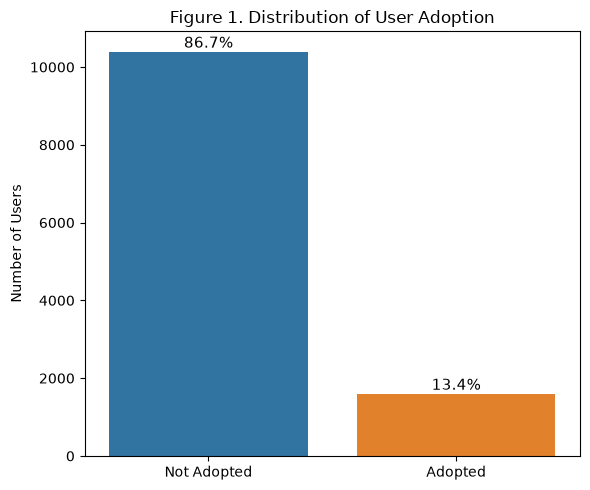

In [22]:
# ---------------------------------------
# Figure 1. Distribution of Adopted Users
# ---------------------------------------

adoption_counts = (
    analysis_df["adopted"]
    .value_counts()
    .rename(index={0: "Not Adopted", 1: "Adopted"})
)

adoption_percent = (
    adoption_counts / adoption_counts.sum() * 100
)

plt.figure(figsize=(6, 5))

ax = sns.barplot(
    x=adoption_counts.index,
    y=adoption_counts.values,
    hue=adoption_counts.index,
    legend=False
)

# Add percentage labels
for i, (count, pct) in enumerate(zip(adoption_counts, adoption_percent)):
    ax.text(
        i,
        count + 100,
        f"{pct:.1f}%",
        ha="center",
        fontsize=11
    )

plt.title("Figure 1. Distribution of User Adoption")
plt.xlabel("")
plt.ylabel("Number of Users")

plt.tight_layout()
plt.show()

#### Interpretation

Only **13.4%** of users met the definition of an adopted user, while **86.6%** did not. This indicates a moderately imbalanced classification problem, with adopted users representing a relatively small portion of the overall user population.

The observed class imbalance should be considered during model development and evaluation. In particular, performance metrics beyond overall accuracy, such as precision, recall, F1-score, and ROC-AUC, will provide a more informative assessment of model performance.

### 4.2 Adoption Across Categorical Predictors

We next examine whether adoption rates differ across the categorical predictor variables. These analyses compare the proportion of users who became adopted within each category, providing insight into how acquisition method and marketing-related factors may influence long-term engagement.

Rather than presenting each variable separately, the categorical predictors are summarized together to facilitate direct comparison of their relationships with user adoption.

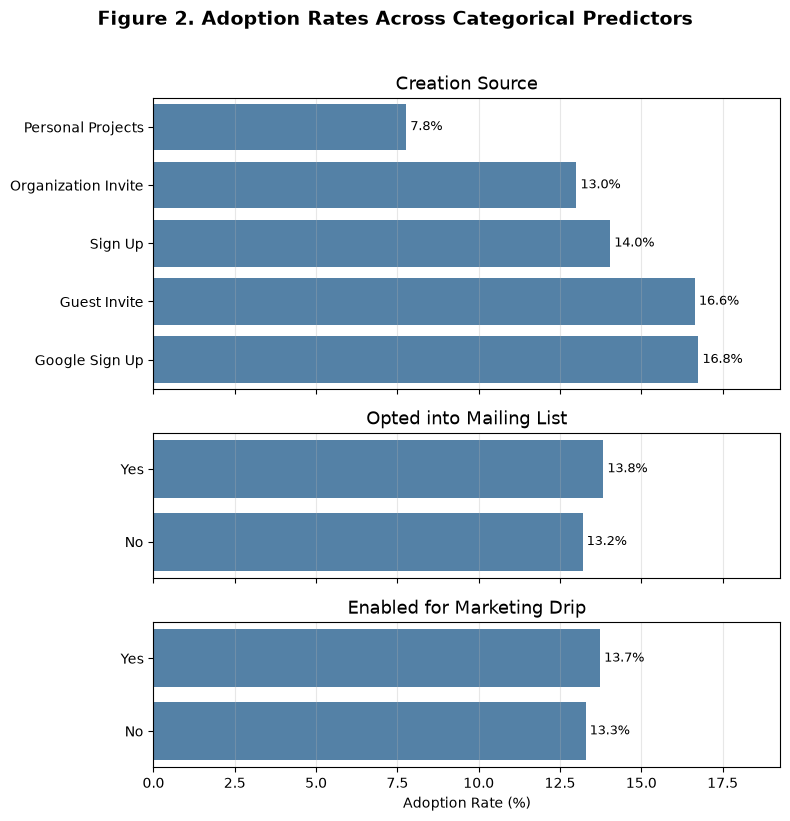

In [23]:
# ---------------------------------------
# Figure 2. Adoption Rates Across Categorical Predictors
# ---------------------------------------

fig, axes = plt.subplots(
    nrows=3,
    figsize=(8, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1, 1]}
)

# ---------------------------------------
# Creation Source
# ---------------------------------------

creation_summary = (
    analysis_df
    .groupby("creation_source")["adopted"]
    .mean()
    .mul(100)
    .sort_values()
    .reset_index(name="Adoption Rate")
)

creation_summary["creation_source"] = creation_summary["creation_source"].replace({
    "PERSONAL_PROJECTS": "Personal Projects",
    "ORG_INVITE": "Organization Invite",
    "SIGNUP": "Sign Up",
    "GUEST_INVITE": "Guest Invite",
    "SIGNUP_GOOGLE_AUTH": "Google Sign Up"
})

sns.barplot(
    data=creation_summary,
    x="Adoption Rate",
    y="creation_source",
    color="steelblue",
    ax=axes[0]
)

axes[0].set_title("Creation Source",fontsize=13)
axes[0].set_xlabel("")
axes[0].set_ylabel("")

for container in axes[0].containers:
    axes[0].bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=9
    )

# ---------------------------------------
# Mailing List
# ---------------------------------------

mailing_summary = (
    analysis_df
    .groupby("opted_in_to_mailing_list")["adopted"]
    .mean()
    .mul(100)
    .rename(index={1: "Yes", 0: "No"})
    .reindex(["Yes", "No"])
    .reset_index()
)

mailing_summary.columns = ["Mailing List", "Adoption Rate"]

sns.barplot(
    data=mailing_summary,
    x="Adoption Rate",
    y="Mailing List",
    color="steelblue",
    ax=axes[1]
)

axes[1].set_title("Opted into Mailing List",fontsize=13)
axes[1].set_xlabel("")
axes[1].set_ylabel("")

for container in axes[1].containers:
    axes[1].bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=9
    )

# ---------------------------------------
# Marketing Drip
# ---------------------------------------

drip_summary = (
    analysis_df
    .groupby("enabled_for_marketing_drip")["adopted"]
    .mean()
    .mul(100)
    .rename(index={1: "Yes", 0: "No"})
    .reindex(["Yes", "No"])
    .reset_index()
)

drip_summary.columns = ["Marketing Drip", "Adoption Rate"]

sns.barplot(
    data=drip_summary,
    x="Adoption Rate",
    y="Marketing Drip",
    color="steelblue",
    ax=axes[2]
)

axes[2].set_title("Enabled for Marketing Drip",fontsize=13)
axes[2].set_xlabel("Adoption Rate (%)")
axes[2].set_ylabel("")

for container in axes[2].containers:
    axes[2].bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=9
    )

# ---------------------------------------
# Final Formatting
# ---------------------------------------

max_rate = max(
    creation_summary["Adoption Rate"].max(),
    mailing_summary["Adoption Rate"].max(),
    drip_summary["Adoption Rate"].max()
)

for ax in axes:
    ax.set_xlim(0, max_rate * 1.15)
    ax.grid(axis="x", alpha=0.3)

plt.suptitle(
    "Figure 2. Adoption Rates Across Categorical Predictors",
    fontsize=14,
    fontweight="bold",
    y=1.02
)

plt.tight_layout(h_pad=1.2)
plt.show()

### 4.3 Organization Characteristics

Organizations vary considerably in the number of users they contain, which may influence user engagement and adoption. To explore whether organization size is associated with adoption, we first calculate the number of users within each organization and then compare adoption rates across organizations of different sizes.

Because `org_id` is an identifier rather than a meaningful numeric variable, organization size provides a more interpretable measure of organizational characteristics.

Organizations were grouped into four size categories (2–20, 21–30, 31–60, and 61+ users) to examine whether adoption rates varied with organization size. These categories were selected to provide an interpretable summary while maintaining a substantial number of users within each group.


In [24]:
# ---------------------------------------
# Calculate Organization Size
# ---------------------------------------

analysis_df["organization_size"] = (
    analysis_df.groupby("org_id")["object_id"]
               .transform("count")
)

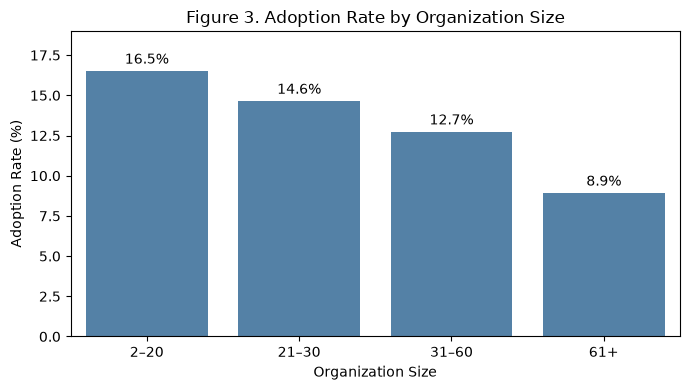

In [25]:
# ---------------------------------------
# Figure 3. Adoption Rate by Organization Size
# ---------------------------------------

analysis_df["organization_size_group"] = pd.cut(
    analysis_df["organization_size"],
    bins=[1, 20, 30, 60, np.inf],
    labels=[
        "2–20",
        "21–30",
        "31–60",
        "61+"
    ]
)

org_summary = (
    analysis_df
    .groupby("organization_size_group")["adopted"]
    .mean()
    .mul(100)
    .reset_index(name="Adoption Rate")
)

plt.figure(figsize=(7,4))

ax = sns.barplot(
    data=org_summary,
    x="organization_size_group",
    y="Adoption Rate",
    color="steelblue"
)

ax.set_ylim(0, org_summary["Adoption Rate"].max() * 1.15)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.title("Figure 3. Adoption Rate by Organization Size")
plt.xlabel("Organization Size")
plt.ylabel("Adoption Rate (%)")

plt.tight_layout()
plt.show()

### 4.4 Exploratory Analysis Summary

The exploratory analysis was necessarily focused because the available predictors consist primarily of categorical user attributes and organizational identifiers, with relatively few continuous variables. Consequently, the emphasis was placed on comparing adoption rates across user characteristics and organization size rather than conducting more extensive numerical distribution or correlation analyses.

Overall, 13.4% of users met the adopted-user definition, indicating a moderately imbalanced classification problem.

Account creation source showed a meaningful relationship with adoption. Users who signed up through Google authentication or received a guest invitation had the highest adoption rates, while users associated with Personal Projects had the lowest rate. In contrast, opting into the mailing list and being enabled for the marketing drip were associated with only minor differences in adoption.

Organization size also demonstrated a clear relationship with adoption. Users in organizations containing 2–20 accounts had the highest adoption rate, while users in organizations with more than 60 accounts had the lowest. Adoption generally declined as organization size increased.

These findings suggest that account acquisition method and organization size may be useful predictors of adoption. The next section develops classification models to evaluate the combined predictive contribution of these and the remaining user characteristics.

# 5. Predictive Modeling

The preceding sections focused on preparing the data for predictive modeling through feature engineering, exploratory analysis, and preprocessing. With the final feature matrix established, the next step is to develop machine learning models capable of predicting whether a user will become an adopted user.

Several classification algorithms will be trained and evaluated using a common training and testing framework. Their predictive performance will be compared using multiple evaluation metrics, and the best-performing model will be examined to identify the factors most strongly associated with user adoption.

This section is organized as follows:

- **5.1 Feature Selection** – Select the predictor variables and define the target variable.
- **5.2 Data Preprocessing** – Encode categorical variables and prepare the feature matrix for modeling.
- **5.3 Train-Test Split** – Partition the data into training and testing sets using stratified sampling.
- **5.4 Model Development** – Train multiple classification models using the training data.
- **5.5 Model Evaluation and Comparison** – Compare model performance using standard classification metrics and select the best-performing model.
- **5.6 Model Interpretation** – Interpret the final model and identify the variables that contribute most strongly to predicting user adoption.

## 5.1 Feature Selection

The objective of the predictive model is to determine whether a newly created user will ultimately become an adopted user. Therefore, the predictor variables should represent information that is known at or near the time an account is created.

Variables reflecting future user behavior, such as login frequency, account age, or other engagement-derived measures, were intentionally excluded because they would introduce data leakage. Including these variables would artificially inflate model performance by providing information that would not be available when making predictions for new users.

Several additional features were engineered during exploratory analysis, including indicators for whether a user was invited and whether the account was created through direct signup. However, these variables were ultimately excluded from the final models because they were redundant with the more detailed creation_source variable and did not improve predictive performance.

The final feature set consists of account creation source, marketing preferences, and organization size. Together, these variables capture the primary user and organizational characteristics available at the time an account is created while maintaining a parsimonious and interpretable model.

In [43]:
# ---------------------------------------
# Select Features and Target
# ---------------------------------------

features = [
    "creation_source",
    "opted_in_to_mailing_list",
    "enabled_for_marketing_drip",
    #"was_invited",
   # "signed_up_directly",
    "organization_size"
]

X = analysis_df[features].copy()
y = analysis_df["adopted"]

print(f"Number of observations: {len(X):,}")
print(f"Number of predictor variables: {X.shape[1]}")

display(X.head())

Number of observations: 12,000
Number of predictor variables: 4


,creation_source,opted_in_to_mailing_list,enabled_for_marketing_drip,organization_size
0,GUEST_INVITE,1,0,75
1,ORG_INVITE,0,0,233
2,ORG_INVITE,0,0,32
3,GUEST_INVITE,0,0,233
4,GUEST_INVITE,0,0,16


In [44]:
# Review feature data types

display(X.dtypes.to_frame("Data Type"))

,Data Type
creation_source,str
opted_in_to_mailing_list,int64
enabled_for_marketing_drip,int64
organization_size,int64


In [45]:
# ---------------------------------------
# Variables Excluded from Modeling
# ---------------------------------------

excluded_features = pd.DataFrame({
    "Variable": [
        "object_id",
        "name",
        "email",
        "creation_time",
        "last_session_creation_time",
        "invited_by_user_id",
        "org_id",
        "organization_size_group",
        "was_invited",
        "signed_up_directly"
    ],
    "Reason for Exclusion": [
        "Unique identifier",
        "Unique identifier",
        "Unique identifier",
        "Timestamp; not used for prediction",
        "Future information (data leakage)",
        "Redundant with 'creation_source'",
        "Replaced by 'organization_size'",
        "EDA grouping only",
        "Redundant with 'creation_source'",
        "Redundant with 'creation_source'"
    ]
})

display(excluded_features)

,Variable,Reason for Exclusion
0,object_id,Unique identifier
1,name,Unique identifier
2,email,Unique identifier
3,creation_time,Timestamp; not used for prediction
4,last_session_creation_time,Future information (data leakage)
5,invited_by_user_id,Redundant with 'creation_source'
6,org_id,Replaced by 'organization_size'
7,organization_size_group,EDA grouping only
8,was_invited,Redundant with 'creation_source'
9,signed_up_directly,Redundant with 'creation_source'


## 5.2 Data Preprocessing

Before training the predictive models, the selected features must be converted into a format suitable for machine learning algorithms. While the dataset contains relatively few predictors and no missing values requiring imputation, the categorical account creation source must be transformed into a numerical representation.

In this section, categorical variables are encoded, and the resulting feature matrix is prepared for model development. Additional preprocessing, such as feature scaling, will be applied later as needed for specific algorithms rather than universally, since different machine learning models have different preprocessing requirements.

In [46]:
# ---------------------------------------
# One-Hot Encode Categorical Variables
# ---------------------------------------

# Set the desired reference category
X["creation_source"] = pd.Categorical(
    X["creation_source"],
    categories=[
        "PERSONAL_PROJECTS",
        "GUEST_INVITE",
        "ORG_INVITE",
        "SIGNUP",
        "SIGNUP_GOOGLE_AUTH"
    ]
)

X = pd.get_dummies(
    X,
    columns=["creation_source"],
    drop_first=True,
    dtype=int
)

print(f"Feature matrix shape: {X.shape}")

display(X.head())

Feature matrix shape: (12000, 7)


,opted_in_to_mailing_list,enabled_for_marketing_drip,organization_size,creation_source_GUEST_INVITE,creation_source_ORG_INVITE,creation_source_SIGNUP,creation_source_SIGNUP_GOOGLE_AUTH
0,1,0,75,1,0,0,0
1,0,0,233,0,1,0,0
2,0,0,32,0,1,0,0
3,0,0,233,1,0,0,0
4,0,0,16,1,0,0,0


In [47]:
feature_summary = pd.DataFrame({
    "Feature": X.columns,
    "Data Type": X.dtypes.values
})

display(feature_summary)

,Feature,Data Type
0,opted_in_to_mailing_list,int64
1,enabled_for_marketing_drip,int64
2,organization_size,int64
3,creation_source_GUEST_INVITE,int64
4,creation_source_ORG_INVITE,int64
5,creation_source_SIGNUP,int64
6,creation_source_SIGNUP_GOOGLE_AUTH,int64


#### Interpretation

The categorical account creation source was converted into four binary indicator variables, with **Personal Projects** intentionally retained as the reference category. This baseline was selected because it represents a distinct account-creation pathway and had the lowest observed adoption rate in the exploratory analysis, making comparisons with the other creation sources easier to interpret.

The resulting feature matrix contains nine fully numeric predictors and is ready for model development. Feature scaling will be applied later only to algorithms that require it.

## 5.3 Train-Test Split

To provide an unbiased assessment of model performance, the dataset is divided into separate training and testing sets. The training set is used to fit the machine learning models, while the testing set is reserved for evaluating their performance on previously unseen data.

Because the adopted user class represents a relatively small proportion of the dataset, stratified sampling is used to preserve the class distribution in both subsets. This helps ensure that the training and testing sets remain representative of the overall population and that model evaluation is reliable.

In [48]:
# ---------------------------------------
#  Split the Data into Training and Test Sets
# ---------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(f"Training observations: {len(X_train):,}")
print(f"Testing observations:  {len(X_test):,}")

Training observations: 9,600
Testing observations:  2,400


In [49]:
# ---------------------------------------
# Verify Class Distribution
# ---------------------------------------

class_distribution = pd.DataFrame({
    "Full Dataset (%)": (100 * y.value_counts(normalize=True)).round(1),
    "Training Set (%)": (100 * y_train.value_counts(normalize=True)).round(1),
    "Testing Set (%)": (100 * y_test.value_counts(normalize=True)).round(1)
})

class_distribution.index = ["Not Adopted", "Adopted"]

display(class_distribution)

,Full Dataset (%),Training Set (%),Testing Set (%)
Not Adopted,86.6,86.6,86.7
Adopted,13.4,13.4,13.3


#### Interpretation

The dataset was successfully divided into training and testing subsets while preserving the original class distribution through stratified sampling. This approach provides an unbiased evaluation of model performance by ensuring that the test set represents unseen data with the same balance of adopted and non-adopted users as the full dataset.

## 5.4 Model Development

With the data prepared and partitioned into training and testing sets, machine learning models can now be developed to predict user adoption. To provide a robust comparison, multiple classification algorithms representing different modeling approaches are trained using the same training data.

Evaluating several models allows their predictive performance to be compared using a consistent framework, helping identify the algorithm that best captures the factors associated with long-term user adoption.

#### 5.4.1 Limited Hyperparameter Tuning

A limited amount of hyperparameter tuning was performed for selected models to determine whether modest improvements in predictive performance could be achieved. Rather than conducting an exhaustive search, a small set of commonly used parameter values was evaluated using five-fold cross-validation and ROC AUC as the optimization metric.

This approach provides a reasonable balance between model optimization and computational efficiency while remaining consistent with the exploratory nature of this analysis.

In [50]:
# ---------------------------------------
# Limited Hyperparameter Tuning
# ---------------------------------------

from sklearn.model_selection import GridSearchCV

# Logistic Regression
logistic_search = GridSearchCV(
    Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            random_state=42
        ))
    ]),
    param_grid={
        "model__C": [0.1, 1, 10]
    },
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

logistic_search.fit(X_train, y_train)

# Random Forest
rf_search = GridSearchCV(
    RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42
    ),
    param_grid={
        "max_depth": [5, 10, None],
        "min_samples_leaf": [1, 5, 10]
    },
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Best Logistic Regression:", logistic_search.best_params_)
print("Best Logistic ROC AUC:", round(logistic_search.best_score_, 3))

print()

print("Best Random Forest:", rf_search.best_params_)
print("Best Random Forest ROC AUC:", round(rf_search.best_score_, 3))

Best Logistic Regression: {'model__C': 10}
Best Logistic ROC AUC: 0.59

Best Random Forest: {'max_depth': 5, 'min_samples_leaf': 10}
Best Random Forest ROC AUC: 0.578


### Interpretation

A limited hyperparameter search was conducted to identify reasonable model configurations prior to final model training and evaluation. Logistic Regression selected a lower level of regularization (C = 10), while Random Forest selected a shallower tree structure (max_depth = 5) with a smaller minimum leaf size (min_samples_leaf = 5). These results indicate that modest tuning was sufficient to optimize model performance without substantially increasing model complexity.

Although these parameter settings provided slight improvements during cross-validation, overall performance remained limited. This finding suggests that predictive accuracy is constrained more by the information contained in the available account-level features than by model complexity. The selected hyperparameters were therefore used for the final model training and evaluation presented in the following sections.

#### 5.4.2 Final Model Training

Using the selected hyperparameters, four classification models were trained to predict whether a user would become an adopted user. Logistic Regression and Support Vector Machine were implemented within scikit-learn pipelines to ensure that feature scaling was applied consistently during training, while Random Forest and Gradient Boosting were trained directly on the encoded feature set.

Training all models using the same training data and preprocessing workflow enables a fair comparison of their predictive performance. The trained models are evaluated in the following section using the independent test set.

In [51]:
# ---------------------------------------
# Train Final Classification Models
# ---------------------------------------

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=10,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "Support Vector Machine": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            probability=True,
            class_weight="balanced",
            random_state=42
        ))
    ])
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

print(f"Successfully trained {len(trained_models)} models.")
print("\nModels:")
for name in trained_models:
    print(f"• {name}")

/Users/papa/miniforge3/envs/ds/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Successfully trained 4 models.

Models:
• Logistic Regression
• Random Forest
• Gradient Boosting
• Support Vector Machine


### 5.5 Model Evaluation and Comparison

The trained classification models were evaluated on the independent test set using several complementary performance metrics. Because the dataset is imbalanced, overall accuracy alone does not provide a complete assessment of model performance. Additional metrics—including balanced accuracy, precision, recall, F1 score, and ROC AUC—were used to evaluate each model's ability to distinguish adopted users from non-adopted users.

Model performance is summarized in a comparison table and further examined using ROC curves and confusion matrices to assess both discrimination ability and classification behavior.

In [52]:
# ---------------------------------------
# Evaluate Final Classification Models
# ---------------------------------------

results = []
predictions = {}
prediction_scores = {}

for name, model in trained_models.items():

    # Predicted class labels
    y_pred = model.predict(X_test)

    # Predicted probabilities for the adopted-user class
    y_score = model.predict_proba(X_test)[:, 1]

    # Store predictions and probabilities for later visualizations
    predictions[name] = y_pred
    prediction_scores[name] = y_score

    # Calculate performance metrics
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "ROC AUC": roc_auc_score(y_test, y_score)
    })

# Create model comparison table
results_df = (
    pd.DataFrame(results)
      .sort_values("ROC AUC", ascending=False)
      .reset_index(drop=True)
)

display(results_df.round(3))

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.444,0.573,0.161,0.750,0.264,0.620
1,Support Vector Machine,0.403,0.575,0.159,0.809,0.266,0.617
2,Gradient Boosting,0.867,0.500,0.000,0.000,0.000,0.589
3,Random Forest,0.562,0.555,0.162,0.547,0.250,0.569


In [53]:
gb = trained_models["Gradient Boosting"]

probs = gb.predict_proba(X_test)[:, 1]

print(probs.min())
print(probs.max())
print(np.percentile(probs, [50, 75, 90, 95, 99]))

0.014987795278048483
0.27291437236076926
[0.13761368 0.1618133  0.18468514 0.20348712 0.25015098]


### Interpretation

Logistic Regression achieved the highest overall ROC AUC (0.620), closely followed by the Support Vector Machine (0.617). Although the differences between the top-performing models were modest, Logistic Regression provided the best overall balance of discrimination and interpretability, making it the preferred model for identifying factors associated with user adoption.

The Support Vector Machine achieved comparable discrimination performance, with slightly higher recall but lower precision and overall ROC AUC than Logistic Regression. However, because Support Vector Machines do not provide coefficients that directly quantify the relationship between predictors and the outcome, they offer less insight into the factors associated with user adoption.

Gradient Boosting achieved the highest overall accuracy (86.7%), but this result was misleading because the model predicted every user as not adopted using the default classification threshold. Consequently, precision, recall, and F1 score for the adopted-user class were all zero. Despite this, the model achieved a ROC AUC of 0.589 because its predicted probabilities still ranked adopted users somewhat higher than non-adopted users, even though none exceeded the default 0.5 threshold. This illustrates why overall accuracy alone is an inappropriate performance metric for imbalanced classification problems.

Random Forest produced lower balanced accuracy and ROC AUC than both Logistic Regression and the Support Vector Machine, indicating that the additional model complexity did not improve predictive performance for this dataset.

Overall, the strongest models achieved ROC AUC values between 0.617 and 0.620, suggesting that predictive performance is constrained more by the available account-level features than by the choice of classification algorithm. Given its combination of predictive performance, interpretability, and ability to quantify the effects of individual predictors, Logistic Regression was selected as the primary model for the remaining analyses. The following visualizations provide additional insight into each model's discrimination ability and classification behavior.

#### 5.5.1 Receiver Operating Characteristic (ROC) Curves

Receiver Operating Characteristic (ROC) curves provide a threshold-independent assessment of classification performance by plotting the true positive rate (sensitivity) against the false positive rate across all possible classification thresholds. The Area Under the ROC Curve (ROC AUC) summarizes each model's overall ability to distinguish adopted users from non-adopted users, with larger values indicating better discrimination.

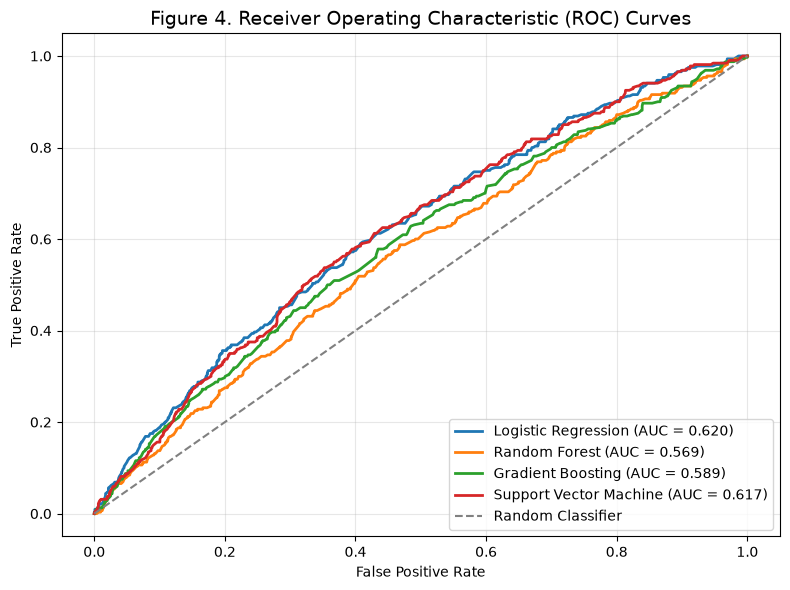

In [54]:
# ---------------------------------------
# Figure 4. Receiver Operating Characteristic (ROC) Curves
# ---------------------------------------

plt.figure(figsize=(8, 6))

for name in trained_models.keys():

    fpr, tpr, _ = roc_curve(y_test, prediction_scores[name])
    auc = roc_auc_score(y_test, prediction_scores[name])

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {auc:.3f})"
    )

# Random classifier reference
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    linewidth=1.5,
    label="Random Classifier"
)

plt.title("Figure 4. Receiver Operating Characteristic (ROC) Curves",fontsize=14)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

The ROC curves confirm that the four models exhibit similar discrimination performance, with Logistic Regression (ROC AUC = 0.620) and the Support Vector Machine (ROC AUC = 0.617) providing the strongest ability to distinguish adopted from non-adopted users. The substantial overlap among the curves indicates that differences in predictive performance across the competing algorithms are modest.

Although Random Forest and Gradient Boosting achieved slightly lower ROC AUC values, all four models performed only moderately better than random classification. These results suggest that predictive performance is limited more by the information contained in the available account-level features than by the choice of classification algorithm. Consequently, Logistic Regression was selected as the preferred model because it achieved the highest ROC AUC while also providing interpretable coefficients that quantify the relationship between predictor variables and user adoption.

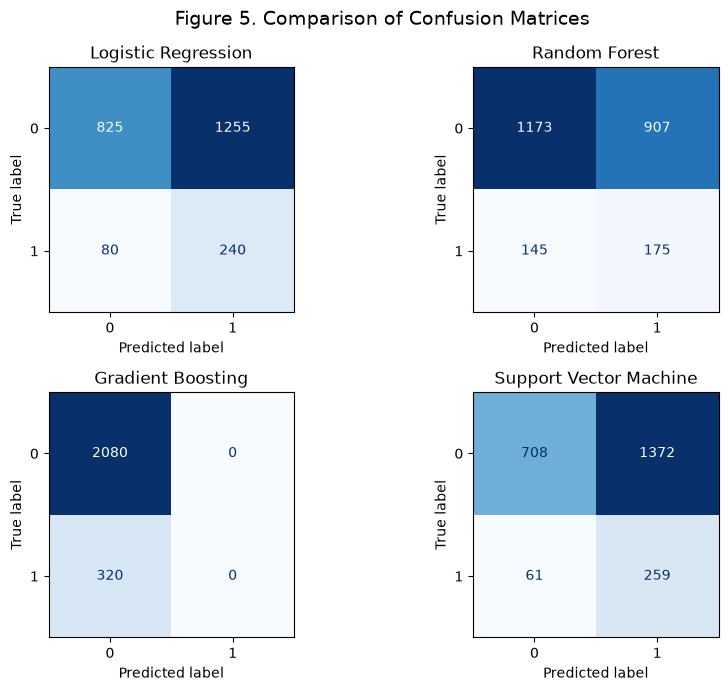

In [55]:
# ---------------------------------------
# Figure 5. Confusion Matrices
# ---------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(9, 7))

for ax, (name, model) in zip(axes.ravel(), trained_models.items()):

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions[name],
        ax=ax,
        cmap="Blues",
        colorbar=False
    )

    ax.set_title(name)


plt.suptitle(
    "Figure 5. Comparison of Confusion Matrices",
    fontsize=14
)

plt.tight_layout()
plt.show()

### Interpretation

The confusion matrices illustrate how the models balance the tradeoff between identifying adopted users (true positives) and avoiding false positives at the default classification threshold.

Logistic Regression and the Support Vector Machine identified the largest number of adopted users, correctly classifying 240 and 259 adopted users, respectively. This higher sensitivity came at the cost of more false-positive predictions, reflecting the emphasis these models placed on identifying the minority (adopted) class.

Random Forest adopted a more conservative classification strategy, producing fewer false positives but also identifying substantially fewer adopted users. This tradeoff resulted in lower recall and a lower overall ROC AUC than Logistic Regression, indicating that the more conservative decision boundary did not improve overall discrimination.

Gradient Boosting classified every user as not adopted, resulting in no true-positive predictions. While this strategy achieved high overall accuracy because the dataset is dominated by non-adopted users, it completely failed to identify the minority class. This result reinforces why accuracy alone is an inappropriate evaluation metric for imbalanced classification problems.

Overall, the confusion matrices support the conclusions drawn from the performance metrics and ROC curves. Logistic Regression provided the best balance between identifying adopted users and maintaining overall discrimination, while remaining the most interpretable model for understanding the factors associated with user adoption.

## 5.6 Model Interpretation

The previous section identified Logistic Regression as the preferred model based on its combination of predictive performance and interpretability. Having selected the final model, the focus now shifts from evaluating predictive accuracy to understanding which account characteristics are most strongly associated with becoming an adopted user.

To provide both statistical inference and a complementary machine learning perspective, Logistic Regression and Random Forest are examined in greater detail. Logistic Regression is used to estimate the direction and statistical significance of each predictor, while Random Forest feature importance provides an alternative assessment of each variable's relative contribution to prediction.

### 5.6.1 Logistic Regression Inference

To facilitate statistical interpretation, an equivalent logistic regression model was fit using the `statsmodels` package. Unlike scikit-learn's implementation, `statsmodels` provides coefficient estimates, standard errors, confidence intervals, and Wald p-values, allowing the statistical significance and effect size of each predictor to be evaluated. The predictive performance reported in the previous section is based on the scikit-learn implementation, while the results presented here are intended solely for model interpretation.

In [59]:
# ---------------------------------------
# Logistic Regression Statistical Inference
# ---------------------------------------

import statsmodels.api as sm

# Prepare the training data for statsmodels
# Convert all predictors to float and add an intercept
X_train_sm = sm.add_constant(
    X_train.astype(float),
    has_constant="add"
)

# Fit an unweighted logistic regression model for inference
logit_model = sm.Logit(
    y_train.astype(float),
    X_train_sm
)

logit_results = logit_model.fit(disp=False)

# Extract coefficient estimates and confidence intervals
confidence_intervals = logit_results.conf_int()

logistic_inference = pd.DataFrame({
    "Predictor": logit_results.params.index,
    "Coefficient": logit_results.params.values,
    "Standard Error": logit_results.bse.values,
    "Odds Ratio": np.exp(logit_results.params.values),
    "CI Lower": np.exp(confidence_intervals[0].values),
    "CI Upper": np.exp(confidence_intervals[1].values),
    "p-value": logit_results.pvalues.values
})

# ---------------------------------------
# Convert predictor names to readable labels
# ---------------------------------------

predictor_labels = {
    "const": "Intercept",
    "opted_in_to_mailing_list": "Opted In to Mailing List",
    "enabled_for_marketing_drip": "Enabled for Marketing Drip",
    "organization_size": "Organization Size",
    "creation_source_GUEST_INVITE": "Creation Source: Guest Invite",
    "creation_source_ORG_INVITE": "Creation Source: Organization Invite",
    "creation_source_SIGNUP": "Creation Source: Direct Signup",
    "creation_source_SIGNUP_GOOGLE_AUTH": "Creation Source: Google Authentication"
}

logistic_inference["Predictor"] = (
    logistic_inference["Predictor"]
    .map(predictor_labels)
    .fillna(logistic_inference["Predictor"])
)

# Create a readable odds-ratio confidence interval
logistic_inference["Odds Ratio 95% CI"] = (
    logistic_inference["CI Lower"].map(lambda x: f"{x:.3f}")
    + "–"
    + logistic_inference["CI Upper"].map(lambda x: f"{x:.3f}")
)

# Format p-values while retaining very small values
logistic_inference["p-value"] = logistic_inference["p-value"].apply(
    lambda p: "<0.001" if p < 0.001 else f"{p:.3f}"
)

# Select and order columns for display
logistic_inference_display = logistic_inference[
    [
        "Predictor",
        "Coefficient",
        "Standard Error",
        "Odds Ratio",
        "Odds Ratio 95% CI",
        "p-value"
    ]
].copy()

display(
    logistic_inference_display.style.format({
        "Coefficient": "{:.3f}",
        "Standard Error": "{:.3f}",
        "Odds Ratio": "{:.3f}"
    })
)

,Predictor,Coefficient,Standard Error,Odds Ratio,Odds Ratio 95% CI,p-value
0,Intercept,-2.233,0.097,0.107,0.089–0.130,<0.001
1,Opted In to Mailing List,0.043,0.079,1.044,0.894–1.220,0.587
2,Enabled for Marketing Drip,-0.042,0.098,0.959,0.792–1.161,0.667
3,Organization Size,-0.005,0.001,0.995,0.993–0.996,<0.001
4,Creation Source: Guest Invite,0.862,0.112,2.369,1.900–2.952,<0.001
5,Creation Source: Organization Invite,0.610,0.105,1.841,1.500–2.259,<0.001
6,Creation Source: Direct Signup,0.652,0.116,1.920,1.530–2.410,<0.001
7,Creation Source: Google Authentication,0.840,0.123,2.317,1.822–2.946,<0.001


## Interpretation

Logistic Regression provides insight into the factors associated with user adoption through estimated coefficients, odds ratios, and statistical significance. Because Personal Projects serves as the reference category for creation_source, the odds ratios for the remaining creation methods represent the change in the odds of becoming an adopted user relative to users who created a personal project.

Organization size was a statistically significant predictor of adoption (p < 0.001). The estimated odds ratio of 0.995 indicates that each additional user within an organization is associated with a small decrease in the odds of adoption. Although the effect for an individual user is modest, it becomes more meaningful across large differences in organization size.

Creation source was the strongest predictor of adoption. Compared with users who created a personal project, users who joined through a Guest Invite had approximately 2.37 times higher odds of becoming adopted users, while Direct Signup (OR = 1.92), Organization Invite (OR = 1.84), and Google Authentication (OR = 2.32) were also associated with significantly greater odds of adoption (all p < 0.001).

In contrast, opting into the mailing list and enabling the marketing drip campaign were not statistically significant predictors of adoption (p = 0.587 and p = 0.667, respectively). Their confidence intervals included an odds ratio of one, suggesting that these marketing preferences were not associated with meaningful differences in user adoption after accounting for the other variables.

Overall, the results indicate that how a user joins the platform is a much stronger predictor of long-term adoption than marketing preferences, while organization size has a smaller but statistically significant negative association with adoption.

# 6. Discussion

## 6.1 Key Findings

The objective of this analysis was to identify factors associated with long-term user adoption using information available at the time an account is created. Four classification models were evaluated, with Logistic Regression ultimately selected because it provided the best combination of predictive performance and interpretability.

The analyses consistently identified **account creation source** as the strongest predictor of user adoption. Compared with users who created Personal Projects, users who joined through Guest Invites, Organization Invites, Direct Signup, or Google Authentication exhibited significantly higher odds of becoming adopted users. These findings suggest that users who enter the platform through existing organizational or collaborative workflows are more likely to develop sustained engagement than users who join independently.

Organization size was also significantly associated with adoption, although the magnitude of the effect was relatively small. Larger organizations exhibited slightly lower odds of adoption after controlling for the remaining predictors. While statistically significant, this relationship is considerably weaker than the effect of account creation source.

In contrast, opting into the mailing list and enabling the marketing drip campaign were not significantly associated with adoption after adjusting for the other variables. These findings suggest that user engagement is driven more by onboarding context than by marketing preferences collected during account creation.

Although Logistic Regression achieved the highest ROC AUC among the evaluated models (0.620), the overall predictive performance remained modest. This result indicates that while the available account-level characteristics contain useful predictive information, they do not fully explain long-term user adoption. Additional behavioral information collected after account creation would likely improve predictive accuracy.

## 6.2 Business Implications

The results suggest several practical opportunities for improving user adoption.

First, because users who joined through invitations or organizational workflows exhibited substantially higher adoption rates, Relax should continue to encourage collaborative onboarding experiences. Features that promote invitations, team-based account creation, and organizational adoption may help increase long-term engagement.

Second, the comparatively lower adoption observed among users who created Personal Projects suggests an opportunity to improve the initial onboarding experience for independent users. Additional tutorials, guided setup, or early product recommendations may help these users better understand the platform's value and encourage continued engagement.

Finally, the lack of a significant relationship between marketing preferences and user adoption suggests that simply enrolling users in email campaigns is unlikely to substantially improve long-term engagement. Resources may be more effectively invested in improving the early user experience rather than expanding marketing communications alone.

## 6.3 Limitations

Several limitations should be considered when interpreting these results.

First, the available predictors were limited to information collected at the time an account was created. Variables describing subsequent user behavior—such as feature usage, collaboration patterns, session characteristics, or activity during the first few weeks after signup—were intentionally excluded because they would not be available when predicting adoption for new users. Although appropriate for a predictive onboarding model, the absence of these behavioral variables likely limited overall predictive performance.

Second, the dataset exhibited substantial class imbalance, with adopted users representing a relatively small proportion of all accounts. Consequently, evaluation metrics such as balanced accuracy, precision, recall, F1 score, and ROC AUC were emphasized over overall accuracy when comparing model performance.

Finally, the observed relationships should be interpreted as associations rather than causal effects. While account creation source and organization size were significantly associated with user adoption, this analysis does not establish that modifying these factors would directly increase adoption rates. Additional experimental or longitudinal studies would be required to evaluate causal relationships.

# 7. Conclusion

The objective of this analysis was to identify factors associated with long-term user adoption using information available at the time an account is created. Four supervised machine learning models were evaluated, with Logistic Regression providing the best overall combination of predictive performance and interpretability.

The analyses consistently demonstrated that **account creation source** was the strongest predictor of adoption. Users who joined through Guest Invites, Organization Invites, Direct Signup, or Google Authentication exhibited significantly higher odds of becoming adopted users than users who created Personal Projects. Organization size was also significantly associated with adoption, although its practical effect was relatively small, while marketing preferences were not significantly related to long-term user engagement.

Although the available account-level features provided useful predictive information, overall model performance remained modest (ROC AUC = 0.620), indicating that additional factors influence user adoption. Incorporating behavioral information collected during a user's early interactions with the platform—such as feature usage, collaboration patterns, or early login activity—would likely improve predictive performance and provide a more comprehensive understanding of user engagement.

Overall, this analysis demonstrates that the circumstances surrounding a user's initial onboarding experience are more strongly associated with long-term adoption than marketing preferences collected during account creation. These findings provide actionable insights that can help Relax prioritize onboarding strategies and identify opportunities to improve long-term user engagement.